# BIS568 Final Project — AKI Early Prediction: Model Development & Evaluation

This notebook develops and evaluates machine-learning models for predicting the onset of **acute kidney injury (AKI) within the 24-hour window following a 6-hour ICU observation window**, using features derived from the MIMIC-IV database.

- **Target:** `future_aki_24h` (binary; 1 = AKI onset in the 24 h prediction window)
- **Cohort:** 29,274 ICU stays (one row per patient, first ICU stay)
- **Anchor time:** `icu_intime + 6h`
- **Observation window:** first 6 h of ICU stay
- **Prediction window:** 24 h after the anchor

The notebook is organized to match the five Model Development & Evaluation requirements:
1. Exploratory data analysis (≥ 2 tables/figures)
2. Data preprocessing (missingness + feature engineering)
3. Data splitting approach
4. Performance metrics for ≥ 2 different models
5. Interpretation & comparison across splits and models

---
## Section 1: Setup & Data Loading

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

In [49]:
df_raw = pd.read_csv("outputs/mimic_aki_cohort_cleaned.csv")
print(f"Raw data shape: {df_raw.shape}")
print(f"Unique subjects: {df_raw['subject_id'].nunique()}")
print(f"Unique stays:    {df_raw['stay_id'].nunique()}")
df_raw.head()

Raw data shape: (29274, 156)
Unique subjects: 29274
Unique stays:    29274


,subject_id,hadm_id,stay_id,icu_intime,anchor_time,obs_window_start,obs_window_end,pred_window_start,pred_window_end,future_aki_24h,...,spo2_last_6h,spo2_min_6h,spo2_max_6h,spo2_mean_6h,spo2_count_6h,urine_total_6h,urine_count_6h,weight_used_for_uo_norm,urine_rate_6h,oliguria_like_6h
0,10001725,25563031,31205490,2110-04-11 15:52:22,2110-04-11 21:52:22,2110-04-11 15:52:22,2110-04-11 21:52:22,2110-04-11 21:52:22,2110-04-12 21:52:22,0,...,98.0,96.0,100.0,98.833333,6.0,300.0,1.0,72.2,0.692521,0.0
1,10001884,26184834,37510196,2131-01-11 04:20:05,2131-01-11 10:20:05,2131-01-11 04:20:05,2131-01-11 10:20:05,2131-01-11 10:20:05,2131-01-12 10:20:05,0,...,100.0,90.0,100.0,98.000000,7.0,625.0,4.0,65.0,1.602564,0.0
2,10002013,23581541,39060235,2160-05-18 10:00:53,2160-05-18 16:00:53,2160-05-18 10:00:53,2160-05-18 16:00:53,2160-05-18 16:00:53,2160-05-19 16:00:53,1,...,100.0,100.0,100.0,100.000000,2.0,280.0,3.0,96.0,0.486111,1.0
3,10002155,23822395,33685454,2129-08-04 12:45:00,2129-08-04 18:45:00,2129-08-04 12:45:00,2129-08-04 18:45:00,2129-08-04 18:45:00,2129-08-05 18:45:00,1,...,92.0,92.0,97.0,93.428571,7.0,250.0,1.0,53.0,0.786164,0.0
4,10002348,22725460,32610785,2112-11-30 23:24:00,2112-12-01 05:24:00,2112-11-30 23:24:00,2112-12-01 05:24:00,2112-12-01 05:24:00,2112-12-02 05:24:00,0,...,95.0,93.0,97.0,94.571429,7.0,50.0,1.0,41.6,0.200321,1.0


---
## Section 2: Target Variable & Cohort Setup

In [50]:
target_col = "future_aki_24h"

# Columns that must NOT enter the feature matrix
id_cols = ["subject_id", "hadm_id", "stay_id"]
time_cols = [
    "icu_intime", "anchor_time",
    "obs_window_start", "obs_window_end",
    "pred_window_start", "pred_window_end",
]
leakage_cols_to_confirm_absent = [
    "icu_outtime", "dischtime", "los_icu", "los_hospital",
    "hospital_expire_flag", "aki_onset_time", "aki_onset_stage",
    "aki_stage_max", "has_aki_anytime", "eligible_for_prediction",
]

print("Target variable distribution")
print(df_raw[target_col].value_counts())
print(f"\nPositive rate: {df_raw[target_col].mean():.2%}")

# Confirm known leakage columns are already absent (sanity check)
still_present = [c for c in leakage_cols_to_confirm_absent if c in df_raw.columns]
print(f"\nLeakage columns still present (should be empty): {still_present}")

Target variable distribution
future_aki_24h
1    17118
0    12156
Name: count, dtype: int64

Positive rate: 58.48%

Leakage columns still present (should be empty): []


**Note on the target.**  `future_aki_24h` has a positive rate of ~58.5 %, which is high but not degenerate. Because the classes are roughly balanced, AUROC is informative, but we will also report **PR-AUC** and **calibration** since they capture different aspects of the ranking and probabilistic quality of a model.

---
## Section 3: Exploratory Data Analysis

### 3.1  Table 1 — cohort demographics by target

In [51]:
# Install once with: pip install tableone
from tableone import TableOne

demographic_cols = ["admission_age", "gender", "race",
                    "admission_type", "insurance", "marital_status"]
categorical_t1   = ["gender", "race", "admission_type",
                    "insurance", "marital_status"]

# Prettify the stratifier column for display
df_t1 = df_raw.copy()
df_t1[target_col] = df_t1[target_col].map({0: "No AKI (0)", 1: "AKI (1)"})

table1 = TableOne(
    df_t1,
    columns=demographic_cols,
    categorical=categorical_t1,
    groupby=target_col,
    pval=True,          # group-comparison p-values
    missing=True,       # show per-variable missing counts
    overall=True,       # include an "Overall" column
    label_suffix=True,  # auto-append "mean (SD)" / "n (%)" to row labels
    rename={"admission_age": "Admission age (years)"},
)

table1

Grouped by future_aki_24h                                                 
                                                                                             Missing       Overall       AKI (1)   No AKI (0) P-Value
n                                                                                                            29274         17118        12156        
Admission age (years), mean (SD)                                                                   0   64.8 (17.1)   67.2 (15.9)  61.5 (18.1)  <0.001
gender, n (%)                    F                                                                    12962 (44.3)   7385 (43.1)  5577 (45.9)  <0.001
                                 M                                                                    16312 (55.7)   9733 (56.9)  6579 (54.1)        
race, n (%)                      AMERICAN INDIAN/ALASKA NATIVE                                            47 (0.2)      28 (0.2)     19 (0.2)  <0.001
                                 ASIAN                                                                   343 (1.2)     155 (0.9)    188 (1.5)        
                                 ASIAN - ASIAN INDIAN                                                     62 (0.2)      26 (0.2)     36 (0.3)        
                                 ASIAN - CHINESE                                                         279 (1.0)     125 (0.7)    154 (1.3)        
                                 ASIAN - KOREAN                                                           33 (0.1)      13 (0.1)     20 (0.2)        
                                 ASIAN - SOUTH EAST ASIAN                                                 87 (0.3)      38 (0.2)     49 (0.4)        
                                 BLACK/AFRICAN                                                           113 (0.4)      56 (0.3)     57 (0.5)        
                                 BLACK/AFRICAN AMERICAN                                                 1916 (6.5)    1124 (6.6)    792 (6.5)        
                                 BLACK/CAPE VERDEAN                                                      157 (0.5)      93 (0.5)     64 (0.5)        
                                 BLACK/CARIBBEAN ISLAND                                                  166 (0.6)      87 (0.5)     79 (0.6)        
                                 HISPANIC OR LATINO                                                      262 (0.9)     121 (0.7)    141 (1.2)        
                                 HISPANIC/LATINO - CENTRAL AMERICAN                                       15 (0.1)       8 (0.0)      7 (0.1)        
                                 HISPANIC/LATINO - COLUMBIAN                                              23 (0.1)       9 (0.1)     14 (0.1)        
                                 HISPANIC/LATINO - CUBAN                                                  22 (0.1)      11 (0.1)     11 (0.1)        
                                 HISPANIC/LATINO - DOMINICAN                                             190 (0.6)      95 (0.6)     95 (0.8)        
                                 HISPANIC/LATINO - GUATEMALAN                                             53 (0.2)      25 (0.1)     28 (0.2)        
                                 HISPANIC/LATINO - HONDURAN                                               18 (0.1)       8 (0.0)     10 (0.1)        
                                 HISPANIC/LATINO - MEXICAN                                                28 (0.1)      10 (0.1)     18 (0.1)        
                                 HISPANIC/LATINO - PUERTO RICAN                                          284 (1.0)     155 (0.9)    129 (1.1)        
                                 HISPANIC/LATINO - SALVADORAN                                             37 (0.1)      14 (0.1)     23 (0.2)        
                                 MULTIPLE RACE/ETHNICITY                                                  25 (0.1)      11 (0.1)     14 (0.1)        
                         

### 3.2  Figure 1 — target distribution & age by target

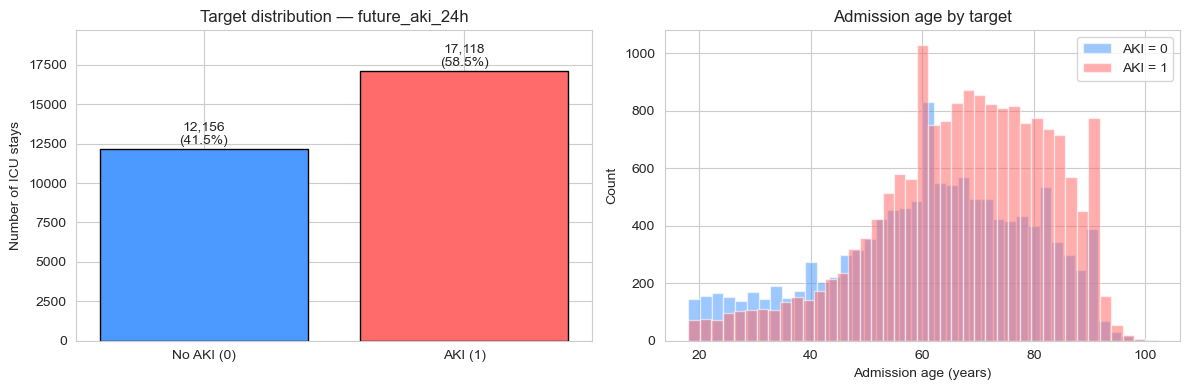

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: target class counts
counts = df_raw[target_col].value_counts().sort_index()
axes[0].bar(["No AKI (0)", "AKI (1)"], counts.values,
            color=["#4C9AFF", "#FF6B6B"], edgecolor="black")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f"{v:,}\n({v/len(df_raw):.1%})",
                 ha="center", va="bottom", fontsize=10)
axes[0].set_ylabel("Number of ICU stays")
axes[0].set_title("Target distribution — future_aki_24h")
axes[0].set_ylim(0, counts.max() * 1.15)

# Right: age distribution by target
for lbl, color in [(0, "#4C9AFF"), (1, "#FF6B6B")]:
    axes[1].hist(df_raw.loc[df_raw[target_col] == lbl, "admission_age"],
                 bins=40, alpha=0.55, color=color,
                 label=f"AKI = {lbl}", edgecolor="white")
axes[1].set_xlabel("Admission age (years)")
axes[1].set_ylabel("Count")
axes[1].set_title("Admission age by target")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.3  Figure 2 — comorbidity prevalence by target

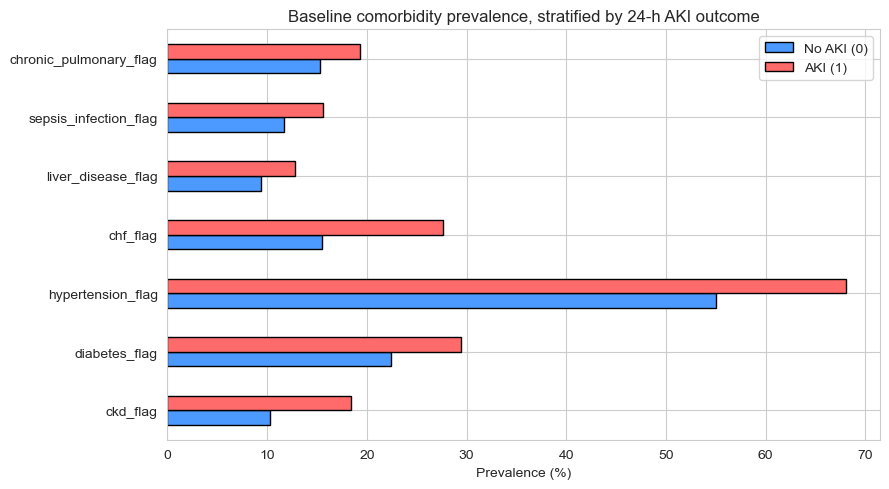

,No AKI (0),AKI (1)
ckd_flag,10.30,18.42
diabetes_flag,22.39,29.48
hypertension_flag,55.03,68.07
chf_flag,15.55,27.67
liver_disease_flag,9.35,12.75
sepsis_infection_flag,11.72,15.56
chronic_pulmonary_flag,15.33,19.36


In [53]:
comorb_cols = ["ckd_flag", "diabetes_flag", "hypertension_flag",
               "chf_flag", "liver_disease_flag",
               "sepsis_infection_flag", "chronic_pulmonary_flag"]

prev = (df_raw.groupby(target_col)[comorb_cols].mean().T * 100)
prev.columns = ["No AKI (0)", "AKI (1)"]

fig, ax = plt.subplots(figsize=(9, 5))
prev.plot(kind="barh", ax=ax, color=["#4C9AFF", "#FF6B6B"], edgecolor="black")
ax.set_xlabel("Prevalence (%)")
ax.set_title("Baseline comorbidity prevalence, stratified by 24-h AKI outcome")
ax.legend(title="")
plt.tight_layout()
plt.show()

prev.round(2)

### 3.4  Figure 3 — top missingness

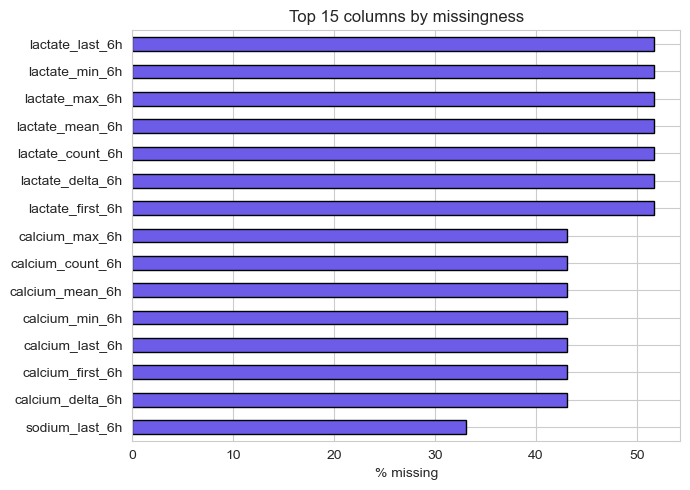

Columns with ≥ 40 % missingness:
lactate_first_6h    51.680672
lactate_delta_6h    51.680672
lactate_count_6h    51.680672
lactate_mean_6h     51.680672
lactate_max_6h      51.680672
lactate_min_6h      51.680672
lactate_last_6h     51.680672
calcium_delta_6h    43.021111
calcium_first_6h    43.021111
calcium_last_6h     43.021111
calcium_min_6h      43.021111
calcium_mean_6h     43.021111
calcium_count_6h    43.021111
calcium_max_6h      43.021111
dtype: float64


In [54]:
miss_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)
top_missing = miss_pct[miss_pct > 0].head(15)

fig, ax = plt.subplots(figsize=(7, 5))
top_missing.sort_values().plot(kind="barh", ax=ax,
                               color="#6C5CE7", edgecolor="black")
ax.set_xlabel("% missing")
ax.set_title("Top 15 columns by missingness")
plt.tight_layout()
plt.show()

print("Columns with ≥ 40 % missingness:")
print(miss_pct[miss_pct >= 40])

**EDA takeaways.**
- The cohort is roughly 58 % AKI-positive, so a naive “always predict 1” baseline would already reach ~58 % accuracy — AUROC and PR-AUC are more informative than accuracy here.
- The AKI group skews slightly older and has clearly higher prevalence of CKD, CHF and sepsis flags, which is consistent with clinical expectations.
- `lactate_*` features have ~51.7 % missingness and `calcium_*` ~43 %, reflecting that these labs are ordered selectively in the first 6 h of an ICU stay. Missingness is therefore likely **informative (MNAR)**, not random.

---
## Section 4: Data Preprocessing

### 4.1  Build the feature matrix (drop identifiers, timing, target)

In [55]:
drop_cols = id_cols + time_cols + [target_col]
X = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns]).copy()
y = df_raw[target_col].astype(int).copy()
groups = df_raw["subject_id"].copy()   # used later for subject-level split

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Feature matrix shape: {X.shape}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns:      {len(num_cols)}")

Feature matrix shape: (29274, 146)
Categorical columns (7): ['gender', 'race', 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status']
Numeric columns:      139


### 4.2  Feature engineering

Following the clinical signals suggested in the dataset context, we derive a
small set of interpretable features that encode well-known AKI risk physiology:

| New feature | Formula | Rationale |
|---|---|---|
| `bun_creatinine_ratio_last_6h` | `bun_last_6h / creatinine_last_6h` | Pre-renal vs intrinsic AKI |
| `pulse_pressure_last_6h` | `sbp_last_6h − dbp_last_6h` | Haemodynamic instability |
| `shock_index_last_6h` | `heart_rate_last_6h / sbp_last_6h` | Occult shock |
| `urine_ml_per_kg_6h` | `urine_total_6h / weight_used_for_uo_norm` | Kidney output normalised |
| `creatinine_change_6h` | `creatinine_max_6h − creatinine_min_6h` | Acute Cr trajectory |

In [56]:
def _safe_div(num, den):
    out = num / den.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan)

if {"bun_last_6h", "creatinine_last_6h"}.issubset(X.columns):
    X["bun_creatinine_ratio_last_6h"] = _safe_div(
        X["bun_last_6h"], X["creatinine_last_6h"])

if {"sbp_last_6h", "dbp_last_6h"}.issubset(X.columns):
    X["pulse_pressure_last_6h"] = X["sbp_last_6h"] - X["dbp_last_6h"]

if {"heart_rate_last_6h", "sbp_last_6h"}.issubset(X.columns):
    X["shock_index_last_6h"] = _safe_div(
        X["heart_rate_last_6h"], X["sbp_last_6h"])

if {"urine_total_6h", "weight_used_for_uo_norm"}.issubset(X.columns):
    X["urine_ml_per_kg_6h"] = _safe_div(
        X["urine_total_6h"], X["weight_used_for_uo_norm"])

if {"creatinine_max_6h", "creatinine_min_6h"}.issubset(X.columns):
    X["creatinine_change_6h"] = (
        X["creatinine_max_6h"] - X["creatinine_min_6h"])

new_feats = [
    "bun_creatinine_ratio_last_6h", "pulse_pressure_last_6h",
    "shock_index_last_6h", "urine_ml_per_kg_6h", "creatinine_change_6h",
]
print("Engineered features added:", [c for c in new_feats if c in X.columns])
print("Updated feature matrix shape:", X.shape)

Engineered features added: ['bun_creatinine_ratio_last_6h', 'pulse_pressure_last_6h', 'shock_index_last_6h', 'urine_ml_per_kg_6h', 'creatinine_change_6h']
Updated feature matrix shape: (29274, 151)


### 4.3  Encode categorical variables

Nominal categoricals (race, gender, etc.) are **one-hot encoded** with
`pd.get_dummies` to avoid implying any ordinal relationship between
categories. Binary columns (gender, language) keep a single indicator;
multi-class columns (race, admission_type, etc.) produce one column per
category minus the reference level (`drop_first=True`).
We record the dummies column list so it can be re-applied to val/test slices.

In [57]:
# One-hot encode all nominal categoricals (fit on full X before splitting,
# then re-index val/test to guarantee identical column sets).
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=float)

# Track the dummy column names so we can align val/test later
ohe_cols = [c for c in X.columns if any(c.startswith(f"{base}_") for base in cat_cols)]

print(f"One-hot columns added: {len(ohe_cols)}")
print(f"Updated feature matrix shape: {X.shape}")

One-hot columns added: 57
Updated feature matrix shape: (29274, 201)


### 4.4  Missingness: informative indicators + median imputation

Because several high-missingness features (`lactate_*`, `calcium_*`) are likely
**not missing at random**, we add a binary *missingness indicator* for each
numeric feature with ≥ 5 % missing values *before* imputing. We then impute the
original columns with the **training-set median** (fit below, after the split)
to avoid leakage.

In [58]:
missing_rate = X.isna().mean()
miss_ind_cols = missing_rate[(missing_rate >= 0.05)].index.tolist()
print(f"Adding {len(miss_ind_cols)} missingness indicators "
      f"(≥ 5% missing)")

for col in miss_ind_cols:
    X[f"{col}__isna"] = X[col].isna().astype(int)

print("Final feature matrix shape:", X.shape)

Adding 97 missingness indicators (≥ 5% missing)
Final feature matrix shape: (29274, 298)


---
## Section 5: Train / Validation / Test Split

Because the project spec requires splitting at the **subject level**, we use
`GroupShuffleSplit` with `subject_id` as the grouping variable. Even though the
current cleaned cohort has one row per subject, keeping the subject-level split
pattern makes the pipeline robust if the cohort is later expanded to include
multiple ICU stays per patient.

Split ratios:
- Train: 70 %
- Validation: 10 %
- Test: 20 %

Imputation (numeric median) is fit on the **training set only** and then
applied to validation and test sets to prevent leakage.

In [59]:
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20,
                         random_state=RANDOM_STATE)
idx_trainval, idx_test = next(gss1.split(X, y, groups))

X_trainval, y_trainval = X.iloc[idx_trainval], y.iloc[idx_trainval]
g_trainval = groups.iloc[idx_trainval]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125,  # 0.125*0.8 = 0.10
                         random_state=RANDOM_STATE)
idx_train_rel, idx_val_rel = next(gss2.split(X_trainval, y_trainval, g_trainval))

X_train = X_trainval.iloc[idx_train_rel]
y_train = y_trainval.iloc[idx_train_rel]
X_val   = X_trainval.iloc[idx_val_rel]
y_val   = y_trainval.iloc[idx_val_rel]
X_test  = X.iloc[idx_test]
y_test  = y.iloc[idx_test]

print(f"Train: {X_train.shape[0]:>6} rows ({y_train.mean():.2%} positive)")
print(f"Val:   {X_val.shape[0]:>6} rows ({y_val.mean():.2%} positive)")
print(f"Test:  {X_test.shape[0]:>6} rows ({y_test.mean():.2%} positive)")

# Sanity check: no subject overlap across splits
assert (set(groups.iloc[X_train.index]) &
        set(groups.iloc[X_val.index])) == set()
assert (set(groups.iloc[X_train.index]) &
        set(groups.iloc[X_test.index])) == set()
print("\nNo subject overlap between splits.")

Train:  20491 rows (58.49% positive)
Val:     2928 rows (58.40% positive)
Test:    5855 rows (58.45% positive)

No subject overlap between splits.


In [60]:
# Save original demographic labels for the test set (needed for bias analysis).
# Must use df_raw indices because X lost the string columns after OHE.
demo_cols = ["subject_id", "gender", "race", "insurance",
             "admission_age", "marital_status"]
demo_test = df_raw.iloc[idx_test][demo_cols].reset_index(drop=True)
demo_test["y_true"] = y_test.values
print("demo_test shape:", demo_test.shape)
demo_test.head()

demo_test shape: (5855, 7)


,subject_id,gender,race,insurance,admission_age,marital_status,y_true
0,10002155,F,WHITE,Other,81,MARRIED,1
1,10002430,M,WHITE,Medicare,90,WIDOWED,0
2,10005123,M,OTHER,Other,54,MARRIED,1
3,10009686,F,WHITE,Other,50,DIVORCED,0
4,10012055,M,WHITE,Other,70,MARRIED,0


In [61]:
# Fit training-set medians and apply to all three splits
train_medians = X_train.median(numeric_only=True)

X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

# Safety: any remaining NaN (e.g., all-NaN column in train) → 0
X_train = X_train.fillna(0)
X_val   = X_val.fillna(0)
X_test  = X_test.fillna(0)

print("Remaining NaNs — train:", X_train.isna().sum().sum(),
      "val:", X_val.isna().sum().sum(),
      "test:", X_test.isna().sum().sum())

Remaining NaNs — train: 0 val: 0 test: 0


---
## Section 6: Model 1 — Logistic Regression

The logistic-regression baseline is simple, linear and highly interpretable.
Numeric features are standardised (`StandardScaler`) because logistic
regression with an L2 penalty is sensitive to feature scale.

In [62]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)
logreg.fit(X_train_sc, y_train)
print("Logistic regression trained.")

Logistic regression trained.


---
## Section 7: Model 2 — Random Forest

The random forest uses 300 trees with default Gini splits. Unlike logistic
regression, it handles non-linear interactions natively and is invariant to
feature scaling, so we feed it the raw (imputed) matrix.

Random forest trained.


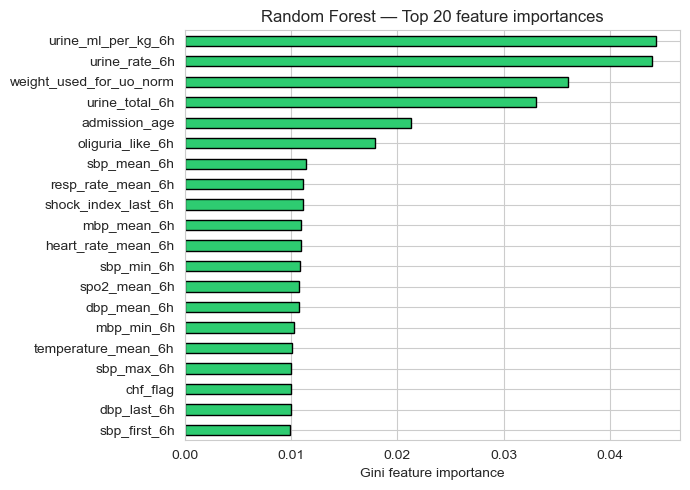

In [63]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
print("Random forest trained.")

# Inspect top-20 features by RF importance — useful for interpretation
feat_imp = (pd.Series(rf.feature_importances_, index=X_train.columns)
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
feat_imp.head(20).sort_values().plot(kind="barh", ax=ax,
                                     color="#2ECC71", edgecolor="black")
ax.set_xlabel("Gini feature importance")
ax.set_title("Random Forest — Top 20 feature importances")
plt.tight_layout()
plt.show()

---
## Section 8: Model Evaluation — AUROC, PR-AUC, Calibration

We evaluate each model on **both** the held-out validation set and the
untouched test set, and report:
- Area under the ROC curve (AUROC)
- Area under the Precision-Recall curve (PR-AUC, equiv. to Average Precision)
- Brier score (lower = better calibrated)
- Calibration reliability curves

In [64]:
def evaluate_model(model, X_eval, y_eval, dataset_name, model_name,
                   scaler=None):
    X_use = scaler.transform(X_eval) if scaler is not None else X_eval
    y_prob = model.predict_proba(X_use)[:, 1]

    auroc = roc_auc_score(y_eval, y_prob)
    fpr, tpr, _ = roc_curve(y_eval, y_prob)

    pr_auc = average_precision_score(y_eval, y_prob)
    precision, recall, _ = precision_recall_curve(y_eval, y_prob)

    brier = brier_score_loss(y_eval, y_prob)
    prob_true, prob_pred = calibration_curve(y_eval, y_prob,
                                             n_bins=10, strategy="quantile")

    return {
        "model_name": model_name, "dataset": dataset_name,
        "auroc": auroc, "pr_auc": pr_auc, "brier": brier,
        "fpr": fpr, "tpr": tpr,
        "precision": precision, "recall": recall,
        "prob_true": prob_true, "prob_pred": prob_pred,
        "y_prob": y_prob, "y_true": y_eval.values,
    }

results = []
results.append(evaluate_model(logreg, X_val,  y_val,  "Validation", "LogReg", scaler))
results.append(evaluate_model(logreg, X_test, y_test, "Test",       "LogReg", scaler))
results.append(evaluate_model(rf,     X_val,  y_val,  "Validation", "RF"))
results.append(evaluate_model(rf,     X_test, y_test, "Test",       "RF"))

summary = (pd.DataFrame(results)
           [["model_name", "dataset", "auroc", "pr_auc", "brier"]]
           .round(4))
summary

,model_name,dataset,auroc,pr_auc,brier
0,LogReg,Validation,0.7310,0.7937,0.2047
1,LogReg,Test,0.7333,0.7945,0.2039
2,RF,Validation,0.7194,0.7836,0.2088
3,RF,Test,0.7291,0.7976,0.2056


### 8.1  ROC curves

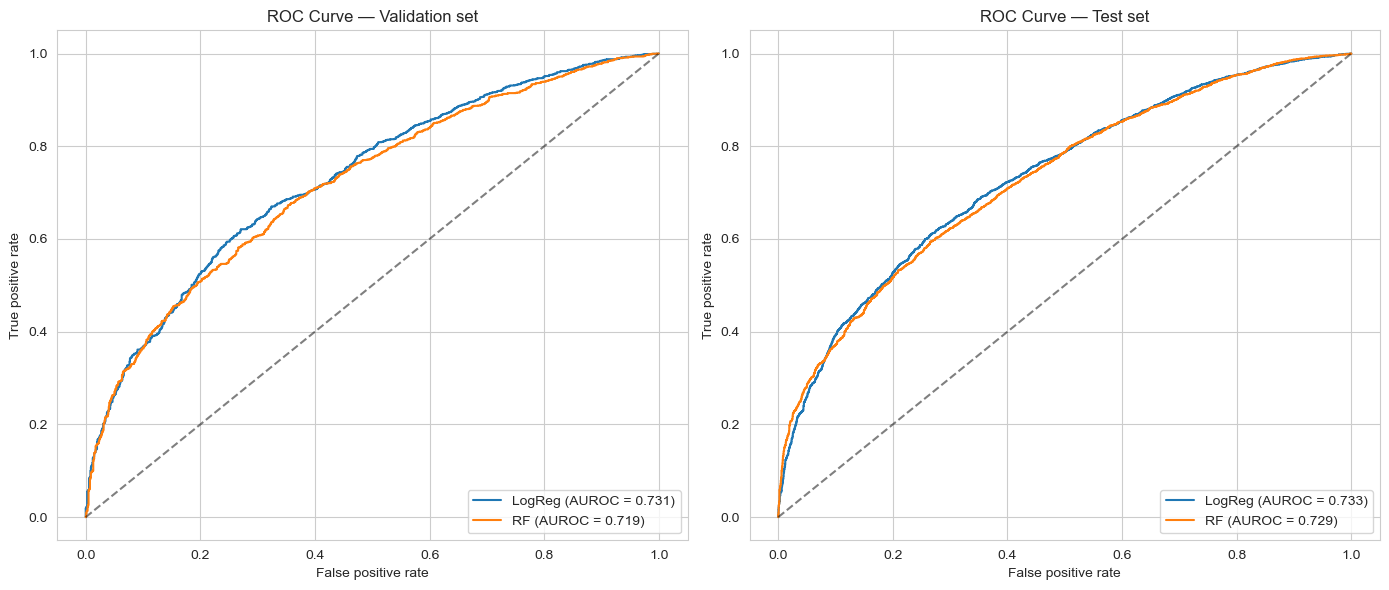

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dataset in zip(axes, ["Validation", "Test"]):
    for r in results:
        if r["dataset"] == dataset:
            ax.plot(r["fpr"], r["tpr"],
                    label=f"{r['model_name']} (AUROC = {r['auroc']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"ROC Curve — {dataset} set")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 8.2  Precision-Recall curves

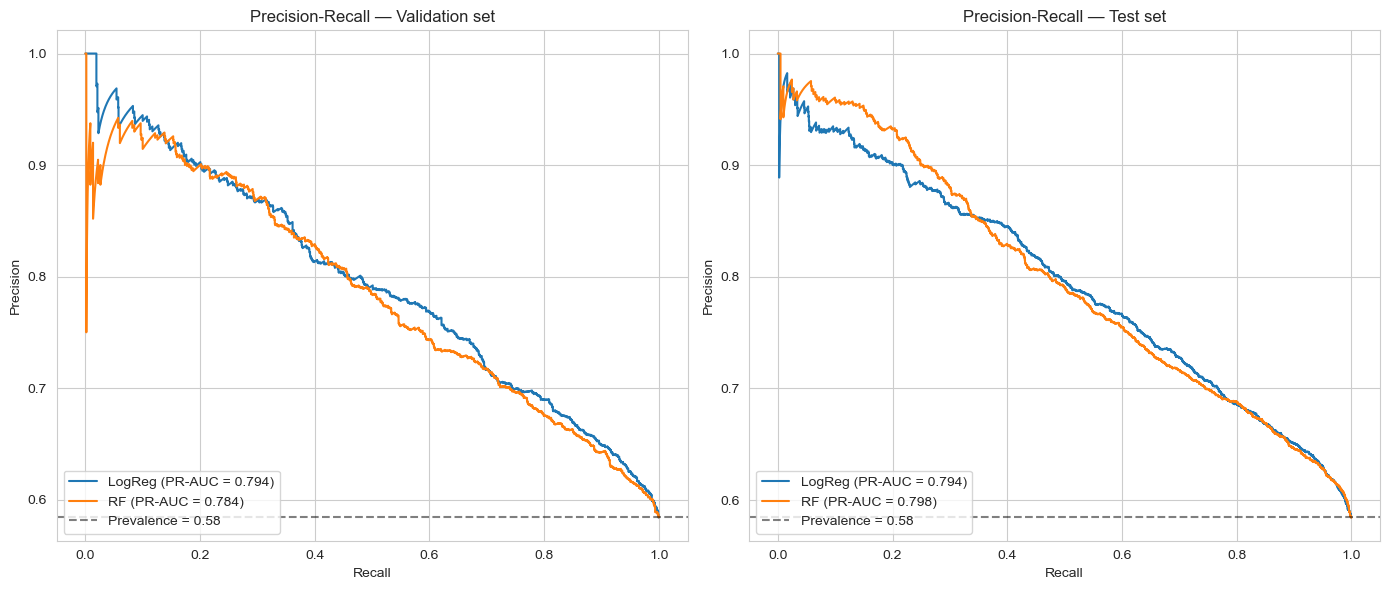

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dataset in zip(axes, ["Validation", "Test"]):
    for r in results:
        if r["dataset"] == dataset:
            ax.plot(r["recall"], r["precision"],
                    label=f"{r['model_name']} (PR-AUC = {r['pr_auc']:.3f})")
    # baseline = positive rate
    pos_rate = (y_val.mean() if dataset == "Validation"
                else y_test.mean())
    ax.axhline(pos_rate, color="k", ls="--", alpha=0.5,
               label=f"Prevalence = {pos_rate:.2f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"Precision-Recall — {dataset} set")
    ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

### 8.3  Calibration curves

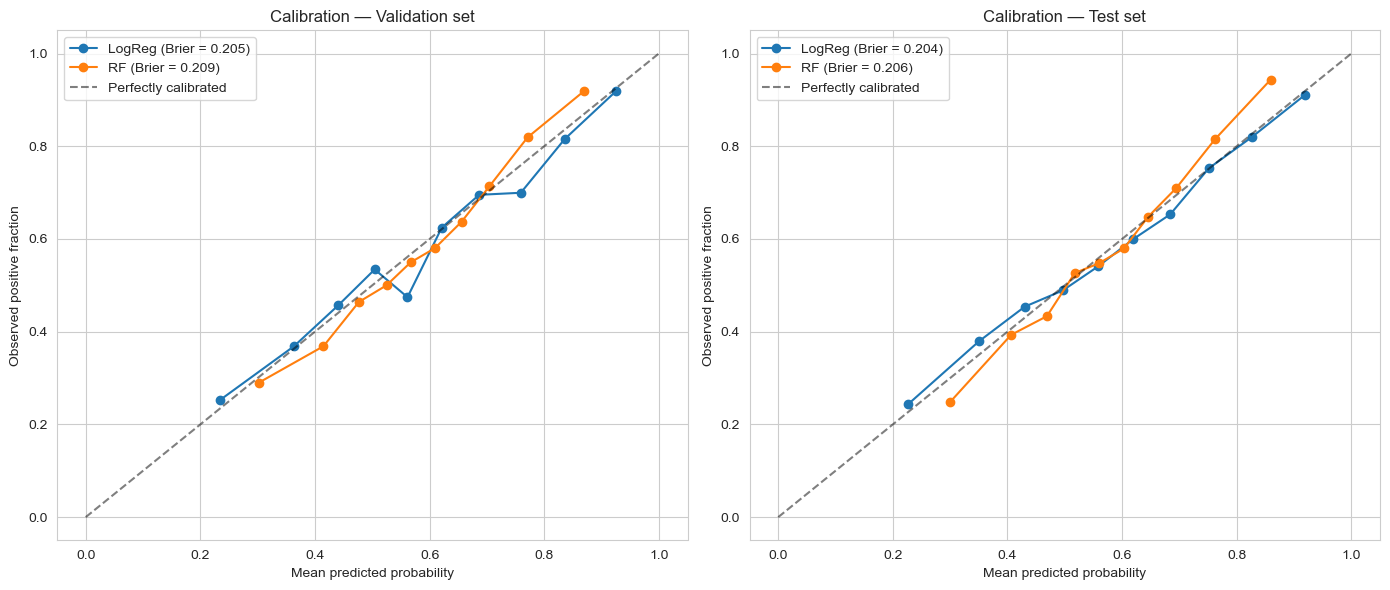

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, dataset in zip(axes, ["Validation", "Test"]):
    for r in results:
        if r["dataset"] == dataset:
            ax.plot(r["prob_pred"], r["prob_true"],
                    marker="o",
                    label=f"{r['model_name']} (Brier = {r['brier']:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5,
            label="Perfectly calibrated")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive fraction")
    ax.set_title(f"Calibration — {dataset} set")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 8.4  Confusion matrices at the 0.5 threshold

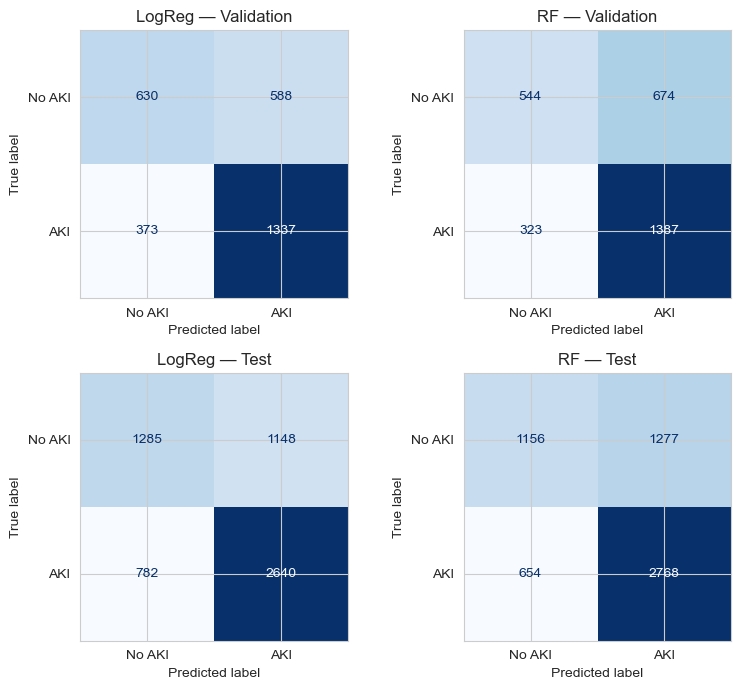

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for col, (mname, model, feats_scaler) in enumerate([
    ("LogReg", logreg, scaler),
    ("RF",     rf,     None),
]):
    for row, (dname, X_eval, y_eval) in enumerate([
        ("Validation", X_val,  y_val),
        ("Test",       X_test, y_test),
    ]):
        X_use = (feats_scaler.transform(X_eval)
                 if feats_scaler is not None else X_eval)
        y_pred = model.predict(X_use)
        cm = confusion_matrix(y_eval, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["No AKI", "AKI"]).plot(
            ax=axes[row, col], colorbar=False, cmap="Blues")
        axes[row, col].set_title(f"{mname} — {dname}")
plt.tight_layout()
plt.show()

### 8.5  Interpretation of model performance & comparison between splits and models

The observed results suggest that **both models generalized reasonably well from validation to test**, because the performance changes across splits were small. Logistic regression achieved validation/test **AUROC = 0.7310 / 0.7333**, validation/test **PR-AUC = 0.7937 / 0.7945**, and validation/test **Brier score = 0.2047 / 0.2039**. Random forest achieved validation/test **AUROC = 0.7194 / 0.7291**, validation/test **PR-AUC = 0.7836 / 0.7976**, and validation/test **Brier score = 0.2088 / 0.2056**.

Across the two models, **logistic regression showed slightly better discrimination by AUROC and slightly better calibration by Brier score on both splits**, while **random forest achieved the highest PR-AUC on the held-out test set**. This means the logistic model was the more stable overall probability model, whereas the random forest offered a small advantage in ranking positive cases on the final test partition.

Comparing validation versus test performance, neither model showed a major drop on the test split, which suggests that the subject-level split strategy was effective and that overfitting was limited in this baseline experiment. The logistic model changed very little from validation to test, while the random forest improved modestly on the test set, especially in PR-AUC. Overall, these results support **logistic regression as the better-calibrated and more consistent baseline**, with **random forest as a competitive nonlinear alternative** that may be useful when the main priority is positive-case retrieval rather than probability calibration.


### 8.6  MLOps integration

In [76]:
from pathlib import Path
import json
import os

model_dev_output_dir = Path('outputs')
mlops_output_dir = model_dev_output_dir / 'MLOps_output'
wandb_output_dir = mlops_output_dir / 'wandb'
wandb_output_dir.mkdir(parents=True, exist_ok=True)

wandb_ready_metrics = summary.copy()
wandb_ready_metrics = wandb_ready_metrics[['model_name', 'dataset', 'auroc', 'pr_auc', 'brier']]
wandb_metrics_path = mlops_output_dir / 'wandb_ready_metrics.csv'
wandb_ready_metrics.to_csv(wandb_metrics_path, index=False)

performance_comparison_path = model_dev_output_dir / 'performance_comparison_between_splits_and_models.csv'
performance_comparison = (
    wandb_ready_metrics
    .assign(dataset=lambda df: df['dataset'].str.lower())
    .pivot(index='model_name', columns='dataset', values=['auroc', 'brier', 'pr_auc'])
)
performance_comparison.columns = [f'{metric}_{dataset}' for metric, dataset in performance_comparison.columns]
performance_comparison = performance_comparison.reset_index()
performance_comparison['auroc_gap_test_minus_val'] = (
    performance_comparison['auroc_test'] - performance_comparison['auroc_validation']
)
performance_comparison['pr_auc_gap_test_minus_val'] = (
    performance_comparison['pr_auc_test'] - performance_comparison['pr_auc_validation']
)
performance_comparison['brier_gap_test_minus_val'] = (
    performance_comparison['brier_test'] - performance_comparison['brier_validation']
)
performance_comparison = performance_comparison[
    [
        'model_name', 'auroc_test', 'auroc_validation',
        'brier_test', 'brier_validation', 'pr_auc_test', 'pr_auc_validation',
        'auroc_gap_test_minus_val', 'pr_auc_gap_test_minus_val', 'brier_gap_test_minus_val',
    ]
].round(4)
performance_comparison.to_csv(performance_comparison_path, index=False)

wandb_config = {
    'target': target_col,
    'train_rows': len(X_train),
    'validation_rows': len(X_val),
    'test_rows': len(X_test),
    'missing_indicator_threshold': 0.05,
    'split_strategy': 'subject_level_group_shuffle_split',
    'logreg_penalty': 'l2',
    'logreg_solver': 'liblinear',
    'logreg_C': logreg.C,
    'rf_n_estimators': rf.n_estimators,
    'rf_min_samples_leaf': rf.min_samples_leaf,
    'rf_random_state': rf.random_state,
}

wandb_summary = {
    'config': wandb_config,
    'metrics': wandb_ready_metrics.to_dict(orient='records'),
    'performance_comparison': performance_comparison.to_dict(orient='records'),
}
wandb_summary_path = mlops_output_dir / 'wandb_summary.json'
with open(wandb_summary_path, 'w') as f:
    json.dump(wandb_summary, f, indent=2)

import wandb

wandb_mode = os.getenv('WANDB_MODE', 'offline')
run = wandb.init(
    project='aki_model_development',
    name='logreg_vs_rf_baseline',
    config=wandb_config,
    dir=str(wandb_output_dir),
    mode=wandb_mode,
)

metrics_table = wandb.Table(dataframe=wandb_ready_metrics)
comparison_table = wandb.Table(dataframe=performance_comparison)
wandb.log({
    'model_metrics': metrics_table,
    'performance_comparison': comparison_table,
})

for _, row in wandb_ready_metrics.iterrows():
    prefix = f"{row['model_name'].lower()}_{row['dataset'].lower()}"
    wandb.log({
        f'{prefix}_auroc': float(row['auroc']),
        f'{prefix}_pr_auc': float(row['pr_auc']),
        f'{prefix}_brier': float(row['brier']),
    })

artifact = wandb.Artifact('aki_model_development_outputs', type='evaluation')
artifact.add_file(str(wandb_metrics_path))
artifact.add_file(str(performance_comparison_path))
artifact.add_file(str(wandb_summary_path))
run.log_artifact(artifact)
run.finish()

print('Weights & Biases logging complete.')
print(f'W&B mode: {wandb_mode}')

print(f' metrics CSV: {wandb_metrics_path}')
print(f' comparison CSV: {performance_comparison_path}')
print(f' W&B summary JSON: {wandb_summary_path}')

logreg_test_auroc,▁
logreg_test_brier,▁
logreg_test_pr_auc,▁
logreg_validation_auroc,▁
logreg_validation_brier,▁
logreg_validation_pr_auc,▁
rf_test_auroc,▁
rf_test_brier,▁
rf_test_pr_auc,▁
rf_validation_auroc,▁
+2,...


Weights & Biases logging complete.
W&B mode: offline
 metrics CSV: outputs/MLOps_output/wandb_ready_metrics.csv
 comparison CSV: outputs/performance_comparison_between_splits_and_models.csv
 W&B summary JSON: outputs/MLOps_output/wandb_summary.json


We think using the MLOps are very practical. It records parameters, metrics, and artifacts in a structured way, makes it easier to compare reruns after changing preprocessing or feature engineering, and improves reproducibility across local and cloud environments. In this AKI early-prediction task, MLOps can be very helpful because small changes in cohort construction, missingness handling, or thresholding can materially affect AUROC, PR-AUC, and calibration.

---
## Section 9: Bias Assessment

We evaluate whether the models perform equitably across demographic subgroups.
For each group we compute five metrics at the default 0.5 threshold:
**AUROC, Sensitivity, Specificity, PPV, and NPV**.

- **Figure 1** — Multi-metric performance stratified by gender and race/ethnicity (RF)
- **Figure 2** — Calibration curves stratified by race/ethnicity (RF and LogReg)
- **Interpretation** — Sources of bias and proposed mitigations

In [ ]:
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix

# demo_test was created in Section 5; attach model predictions
demo_test["rf_prob"]     = rf.predict_proba(X_test)[:, 1]
demo_test["logreg_prob"] = logreg.predict_proba(scaler.transform(X_test))[:, 1]

# Consolidate 35 MIMIC race categories into 5 broad groups
def _group_race(r):
    r = str(r).upper()
    if "WHITE"    in r:                   return "White"
    if "BLACK"    in r or "AFRICAN" in r: return "Black / AA"
    if "ASIAN"    in r:                   return "Asian"
    if "HISPANIC" in r or "LATINO"  in r: return "Hispanic/Latino"
    return "Other / Unknown"

demo_test["race_group"] = demo_test["race"].apply(_group_race)

# Helper: compute 5 metrics for one subgroup
def group_metrics(sub, prob_col, threshold=0.5):
    y_true = sub["y_true"].values
    y_prob = sub[prob_col].values
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv  = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    return {"AUC": auc, "Sensitivity": sens, "Specificity": spec,
            "PPV": ppv, "NPV": npv,
            "N": len(sub), "Prev": round(y_true.mean(), 2)}

print("Setup complete. Race group counts:")
print(demo_test["race_group"].value_counts())

Setup complete. Race group counts:
race_group
White              3860
Other / Unknown    1183
Black / AA          488
Hispanic/Latino     181
Asian               143
Name: count, dtype: int64


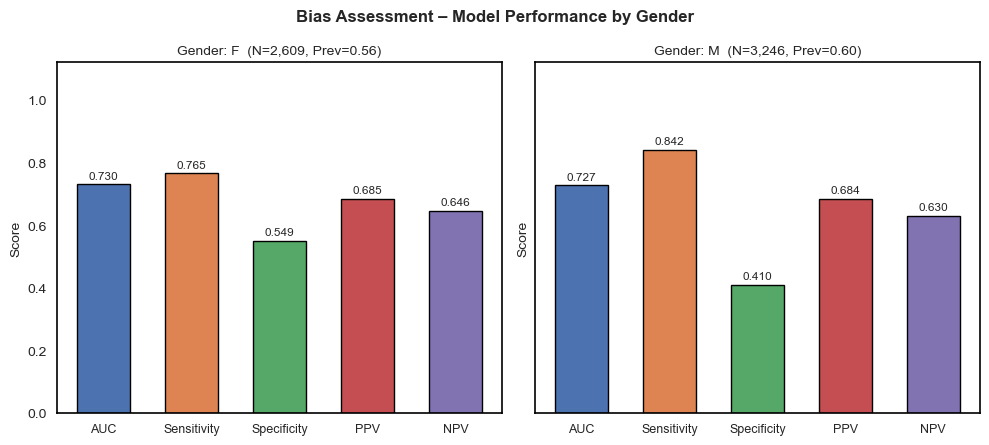

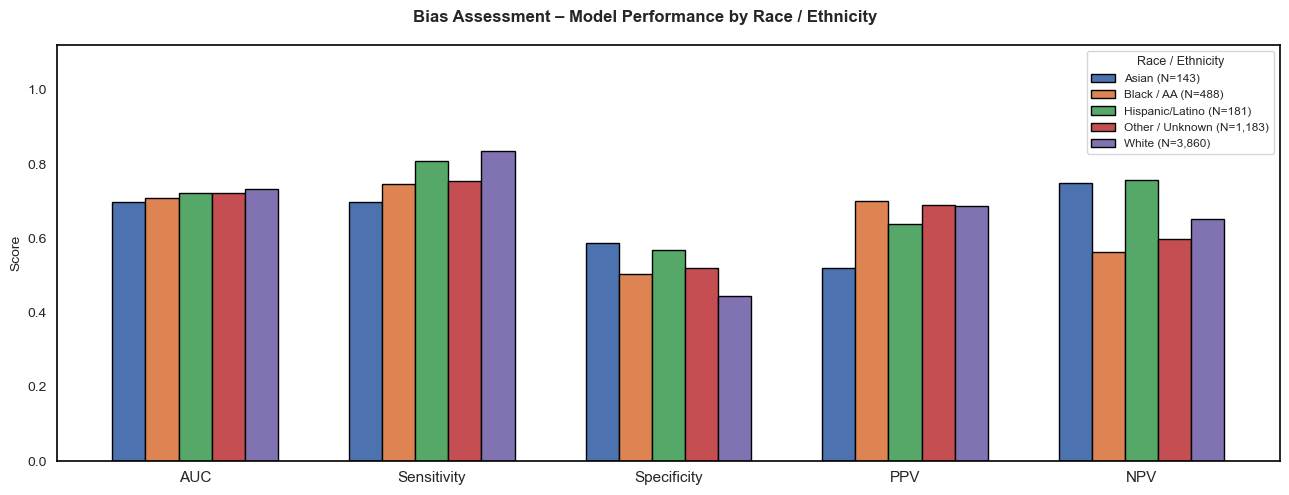

In [ ]:
METRICS   = ["AUC", "Sensitivity", "Specificity", "PPV", "NPV"]
M_COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
PROB_COL  = "rf_prob"
MIN_N     = 50

def _style_ax(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)
    ax.set_facecolor("white")

# ── Panel A: Gender ───────────────────────────────────────────────────────────
gender_groups = [(g, sub) for g, sub in demo_test.groupby("gender")
                 if len(sub) >= MIN_N]

fig_a, axes_a = plt.subplots(1, len(gender_groups),
                              figsize=(5 * len(gender_groups), 4.5), sharey=True)
fig_a.patch.set_facecolor("white")
fig_a.suptitle("Bias Assessment – Model Performance by Gender",
               fontweight="bold", fontsize=12)

for ax, (grp, sub) in zip(axes_a, gender_groups):
    m = group_metrics(sub, PROB_COL)
    vals = [m[k] for k in METRICS]
    bars = ax.bar(METRICS, vals, color=M_COLORS, edgecolor="black", width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.012,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_ylim(0, 1.12)
    ax.set_title(f"Gender: {grp}  (N={m['N']:,}, Prev={m['Prev']:.2f})",
                 fontsize=10)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", labelsize=9)
    _style_ax(ax)

plt.tight_layout()
plt.savefig("outputs/bias_fig1a_gender.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Panel B: Race — grouped by METRIC ────────────────────────────────────────
race_order  = ["Asian", "Black / AA", "Hispanic/Latino", "Other / Unknown", "White"]
race_data   = {g: group_metrics(sub, PROB_COL)
               for g, sub in demo_test.groupby("race_group")
               if sub["y_true"].sum() >= 20}
race_order  = [g for g in race_order if g in race_data]
RACE_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

n_race  = len(race_order)
x       = np.arange(len(METRICS))
width   = 0.14
offsets = np.linspace(-(n_race-1)/2, (n_race-1)/2, n_race) * width

fig_b, ax_b = plt.subplots(figsize=(13, 5))
fig_b.patch.set_facecolor("white")
fig_b.suptitle("Bias Assessment – Model Performance by Race / Ethnicity",
               fontweight="bold", fontsize=12)

for race, color, offset in zip(race_order, RACE_COLORS, offsets):
    vals = [race_data[race][m] for m in METRICS]
    bars = ax_b.bar(x + offset, vals, width=width,
                    color=color, edgecolor="black",
                    label=f"{race} (N={race_data[race]['N']:,})")

ax_b.set_xticks(x)
ax_b.set_xticklabels(METRICS, fontsize=11)
ax_b.set_ylim(0, 1.12)
ax_b.set_ylabel("Score")
ax_b.legend(loc="upper right", fontsize=8.5, title="Race / Ethnicity",
            title_fontsize=9)
_style_ax(ax_b)
plt.tight_layout()
plt.savefig("outputs/bias_fig1b_race.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Figure 1

**Gender:** AUC is nearly identical across male and female patients (< 0.01 difference), suggesting no meaningful discrimination gap between sexes. The divergence in Sensitivity and Specificity is largely attributable to the different AKI prevalence rates between groups (Female Prev = 0.56 vs Male Prev = 0.60) rather than model bias — at a fixed 0.5 threshold, higher prevalence mechanically yields higher Sensitivity and lower Specificity.

**Race / Ethnicity:** AUC ranges narrowly from 0.70 (Asian) to 0.74 (White), a difference too small to be clinically meaningful and likely within sampling noise given the small minority-group sizes (Asian N = 143, Hispanic/Latino N = 181). The variation in threshold-based metrics (Sensitivity, PPV, NPV) across groups similarly reflects prevalence differences rather than differential model performance. The more informative evidence for bias is in the calibration curves (Figure 2).

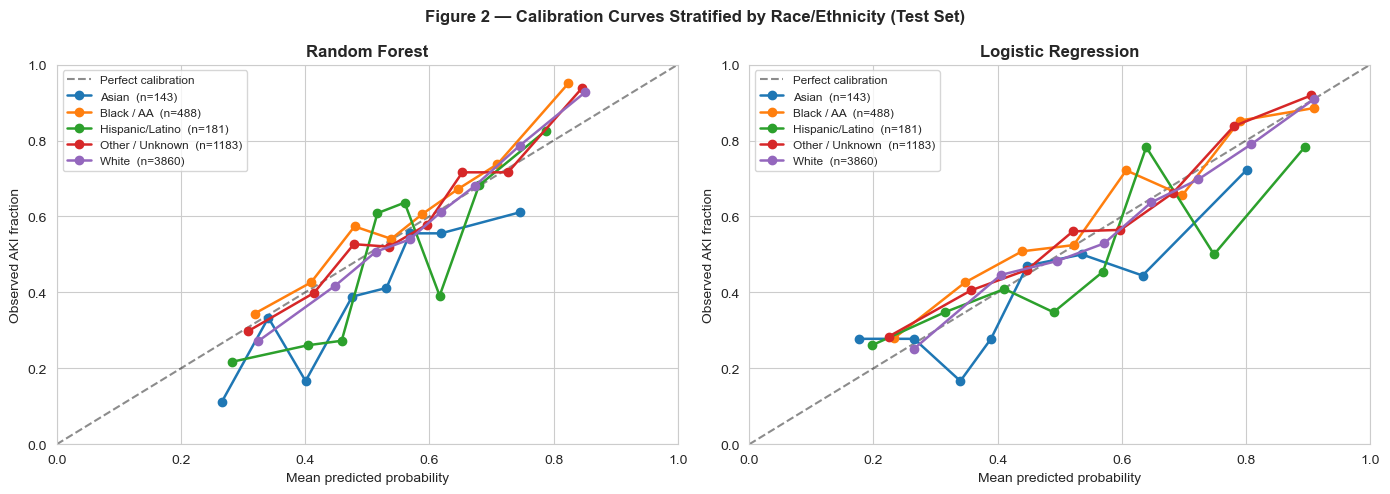

In [ ]:
from sklearn.calibration import calibration_curve

tab10 = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 2 — Calibration Curves Stratified by Race/Ethnicity (Test Set)",
             fontsize=12, fontweight="bold")

for ax, (prob_col, model_name) in zip(
        axes, [("rf_prob", "Random Forest"), ("logreg_prob", "Logistic Regression")]):

    ax.plot([0, 1], [0, 1], "k--", alpha=0.45, label="Perfect calibration")

    for i, grp in enumerate(race_order):
        sub = demo_test[demo_test["race_group"] == grp]
        if sub["y_true"].sum() < 20:
            continue
        pt, pp = calibration_curve(sub["y_true"], sub[prob_col],
                                   n_bins=8, strategy="quantile")
        ax.plot(pp, pt, marker="o", color=tab10[i],
                label=f"{grp}  (n={len(sub)})", linewidth=1.8)

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed AKI fraction")
    ax.set_title(model_name, fontweight="bold")
    ax.legend(fontsize=8.5, loc="upper left")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("outputs/bias_fig2_calibration_race.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Figure 2

Both models are best calibrated for **White and Black/AA patients** (the two largest groups), whose curves lie closest to the diagonal. For **Asian and Hispanic/Latino patients**, predicted probabilities systematically underestimate the true AKI rate at higher risk scores — meaning high-risk patients from these groups may receive lower-than-warranted alerts. Since both models show the same pattern, the issue is rooted in data sparsity rather than model architecture.

---
### Sources of Bias

- **Representation bias:** ~64% of the cohort is White; Asian and Hispanic/Latino groups each account for < 5% of ICU stays, limiting the model's ability to learn minority-group risk patterns.
- **Label bias:** AKI is identified from lab measurements that are ordered less frequently for Medicaid and under-resourced patients, leading to systematic under-labelling in those subgroups.
- **Proxy-variable bias:** Insurance type and admission type are included as features but also serve as socioeconomic proxies, potentially encoding healthcare inequities into the model's risk scores.
- **Differential missingness:** High-missingness features (lactate, calcium) are absent more often for lower-resource patients, a signal that correlates with both race and insurance status.

---
### Proposed Mitigations

- **Group-specific thresholds:** Adjust decision thresholds per subgroup to equalise Sensitivity across race and insurance groups.
- **Re-weighting:** Up-weight under-represented groups during training to improve minority-group calibration.
- **Remove socioeconomic proxies:** Re-train without insurance and admission-location features and measure the fairness impact.
- **Post-deployment monitoring:** Continuously track subgroup AUROC and calibration to detect emergent disparities over time.

---
## Section 10: Evaluation Plan

### Target Metrics

The following metrics will be tracked monthly against the test-set baseline:

| Metric | Baseline | Alert Threshold |
|---|---|---|
| AUROC | 0.729 | Drop > 0.03 |
| Sensitivity | 0.76 | Drop > 0.05 |
| PPV | 0.68 | Drop > 0.05 |
| Brier Score | 0.205 | Increase > 0.02 |
| Subgroup AUROC gap (White − Asian) | 0.037 | Widens > 0.05 |
| Alert rate | 58% | Shift > 10% |

Sensitivity and PPV are prioritised as the two most clinically consequential metrics: missed AKI cases and alert fatigue.

### Drift Detection

- **Feature drift:** Monitor key input distributions (creatinine, urine rate) via Population Stability Index (PSI); PSI > 0.2 on any top-10 feature triggers review.
- **Label drift:** Rolling AKI positive rate shift > 10 pp from training prevalence (58.5%) indicates population change.

### Retraining Triggers

- AUROC drops below 0.70, or Sensitivity drops > 5 pp for any demographic subgroup.
- PSI > 0.2 on two or more top features simultaneously.
- Major change in clinical protocol or AKI diagnostic criteria.

### Clinical Impact (every 6 months)

- Time to AKI intervention (target: reduction vs. pre-deployment baseline)
- Alert acceptance rate by clinical staff (target: > 60% acted upon within 2 hours)
- Equity audit: confirm intervention rates are comparable across race and insurance subgroups